# ABV 5 - Data Visualization I
## Daten laden, bereinigen, analysieren und visualisieren

Dieses Aufgabenblatt begleitet die erste Einheit zur Datenanalyse mit `pandas` und `matplotlib`.
Die Grundlage bildet ein Beispieldatensatz aus einem kleinen Buchungssystem.

| # | Thema | Methoden / Konzepte |
|---|-------|----------------------|
| 1 | Daten einlesen und verstehen | `read_csv`, `head`, `info`, `dtypes`, `columns` |
| 2 | Datenbereinigung | `isna`, `fillna`, Datumsformate, Filter |
| 3 | Erste Auswertungen | `describe`, `value_counts` |
| 4 | Feature Engineering | neue Spalten mit logischen Bedingungen und Datumsdifferenzen |
| 5 | Visualisierung | `groupby`, Zeitreihenaggregation, Balkendiagramm |

Bearbeiten Sie die Aufgaben nacheinander. Unter jeder Aufgabe finden Sie ein kurzes Beispiel und aufklappbare Tipps.

In [25]:
import pandas as pd

titanic = pd.read_csv('titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Teil 1 - Datensatz laden und erkunden

### Aufgabe 1 - Erste Orientierung im Datensatz

Laden Sie den Datensatz `buchungen_2025.csv` in ein DataFrame namens `df`.

**a)** Geben Sie die ersten fünf Zeilen des Datensatzes aus.

**b)** Untersuchen Sie die Struktur des DataFrames mit `.info()`, `.dtypes` und `.columns`.

**c)** Beantworten Sie anschließend eine Frage auf Basis dieser Methoden:
- Welche Spalten enthalten Datumswerte, sind aber noch keine echten Datumsobjekte?
- Welche Spalten sind numerisch und welche sind textbasiert?
- Welche Spaltennamen könnten für eine Umsatzanalyse besonders relevant sein?

<details>
<summary><b>Tipp zu a) - CSV-Datei laden</b></summary>

Verwenden Sie `pd.read_csv(...)` und speichern Sie das Ergebnis in einer Variablen, damit Sie im restlichen Notebook damit weiterarbeiten koennen.
</details>

<details>
<summary><b>Tipp zu b) - Struktur untersuchen</b></summary>

- `df.info()` zeigt Anzahl der Eintraege und Datentypen
- `df.dtypes` zeigt die Datentypen pro Spalte
- `df.columns` gibt alle Spaltennamen aus
</details>

<details>
<summary><b>Tipp zu c) - Beobachtungen formulieren</b></summary>

Es geht nicht nur um die Ausgabe der Methoden, sondern auch darum, die Ergebnisse inhaltlich zu interpretieren. Schreiben Sie ruhig einen kurzen Kommentar unter Ihren Code.
</details>

In [30]:
import pandas as pd

# Ihre Loesung hier:
df = pd.read_csv('buchungen_2025.csv')
df

,booking_id,booking_date,due_date,payment_date,fiscal_year,month,quarter,document_number,document_type,booking_type,...,amount_net,vat_rate,vat_amount,amount_gross,currency,is_paid,is_recurring,has_attachment,is_credit_note,notes
0,1,2025-05-21,2025-05-28,2025-06-24,2025,5,Q2,DOC-2025-0001,invoice,expense,...,629.38,0.19,119.58,748.96,EUR,True,False,True,False,NaN
1,2,2025-12-26,2026-01-25,2026-01-12,2025,12,Q4,DOC-2025-0002,invoice,revenue,...,1312.64,0.19,249.40,1562.04,EUR,True,False,True,False,Workshop
2,3,2025-07-14,2025-08-13,NaN,2025,7,Q3,DOC-2025-0003,invoice,revenue,...,1157.85,0.19,219.99,1377.84,EUR,False,False,False,False,NaN
3,4,2025-11-13,2025-11-20,2025-11-17,2025,11,Q4,DOC-2025-0004,receipt,revenue,...,1976.63,0.19,375.56,2352.19,EUR,True,False,True,False,Workshop
4,5,2025-03-25,2025-04-08,2025-03-29,2025,3,Q1,DOC-2025-0005,invoice,expense,...,123.65,0.19,23.49,147.14,EUR,True,True,True,False,SaaS Abo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,2025-03-07,2025-04-06,2025-03-27,2025,3,Q1,DOC-2025-0296,invoice,expense,...,164.91,0.19,31.33,196.24,EUR,True,False,True,False,Onlinekampagne
296,297,2025-08-20,2025-09-19,2025-09-21,2025,8,Q3,DOC-2025-0297,invoice,expense,...,245.34,0.19,46.61,291.95,EUR,True,True,False,False,SaaS Abo
297,298,2025-05-29,2025-06-05,NaN,2025,5,Q2,DOC-2025-0298,receipt,revenue,...,1588.89,0.19,301.89,1890.78,EUR,False,False,True,False,Workshop
298,299,2025-09-03,2025-10-03,NaN,2025,9,Q3,DOC-2025-0299,receipt,expense,...,220.67,0.07,15.45,236.12,EUR,False,False,True,False,Dienstreise


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   booking_id            300 non-null    int64  
 1   booking_date          300 non-null    str    
 2   due_date              300 non-null    str    
 3   payment_date          212 non-null    str    
 4   fiscal_year           300 non-null    int64  
 5   month                 300 non-null    int64  
 6   quarter               300 non-null    str    
 7   document_number       290 non-null    str    
 8   document_type         300 non-null    str    
 9   booking_type          300 non-null    str    
 10  account_code          300 non-null    int64  
 11  account_name          300 non-null    str    
 12  counter_account_code  300 non-null    int64  
 13  counter_account_name  300 non-null    str    
 14  statement_section     300 non-null    str    
 15  category              300 non-null

In [4]:
df.dtypes

booking_id                int64
booking_date                str
due_date                    str
payment_date                str
fiscal_year               int64
month                     int64
quarter                     str
document_number             str
document_type               str
booking_type                str
account_code              int64
account_name                str
counter_account_code      int64
counter_account_name        str
statement_section           str
category                    str
partner_name                str
cost_center                 str
payment_method              str
quantity                  int64
unit_price_net          float64
amount_net              float64
vat_rate                float64
vat_amount              float64
amount_gross            float64
currency                    str
is_paid                    bool
is_recurring               bool
has_attachment             bool
is_credit_note             bool
notes                       str
dtype: o

In [5]:
df.columns
len(df.columns)

31

In [6]:
Nullwerte = df['payment_date'].isnull().sum()
print(Nullwerte)

88


---
## Teil 2 - Datenbereinigung

### Aufgabe 2 - Fehlende Werte, Zahlungsstatus und Datumsformate

Bereinigen und verbessern Sie den Datensatz.

**a)** Ermitteln Sie, wie viele fehlende Werte pro Spalte vorhanden sind.

**b)** Waehlen Sie eine sinnvolle Spalte mit fehlenden numerischen Werten und fuellen Sie die fehlenden Eintraege testweise mit dem Mittelwert auf.

**c)** Bestimmen Sie, wie viele Buchungen bereits bezahlt wurden.

**d)** Konvertieren Sie die Datums-Spalten in echte Datumsdatentypen. Besonders relevant sind `booking_date`, `due_date` und `payment_date`.


<details>
<summary><b>Tipp zu a) - Fehlende Werte finden</b></summary>

Mit `df.isna().sum()` erhalten Sie fuer jede Spalte die Anzahl fehlender Werte. Achten Sie darauf, welche Spalten besonders betroffen sind.
</details>

<details>
<summary><b>Tipp zu b) - Mittelwert verwenden</b></summary>

Der Mittelwert eignet sich nur fuer numerische Spalten. Sie koennen z. B. `unit_price_net` oder `quantity` pruefen.
```python
df["unit_price_net"] = df["unit_price_net"].fillna(df["unit_price_net"].mean())
```
</details>

<details>
<summary><b>Tipp zu c) - Bereits bezahlte Buchungen zaehlen</b></summary>

Da `is_paid` boolesche Werte enthaelt, koennen Sie die Anzahl bezahlter Buchungen direkt ueber `sum()` bestimmen.
</details>

<details>
<summary><b>Tipp zu d) - Datumsformate umwandeln</b></summary>

Verwenden Sie `pd.to_datetime(...)`. Danach koennen Sie mit `.dt` auf Datumskomponenten zugreifen.
</details>

In [7]:
# Ihre Loesung hier:
Zero = df.isna().sum()
print(Zero)

booking_id               0
booking_date             0
due_date                 0
payment_date            88
fiscal_year              0
month                    0
quarter                  0
document_number         10
document_type            0
booking_type             0
account_code             0
account_name             0
counter_account_code     0
counter_account_name     0
statement_section        0
category                 0
partner_name             0
cost_center              0
payment_method           0
quantity                 0
unit_price_net           0
amount_net               0
vat_rate                 0
vat_amount               0
amount_gross             0
currency                 0
is_paid                  0
is_recurring             0
has_attachment           0
is_credit_note           0
notes                   35
dtype: int64


In [8]:
##c)
bezahlt = df[df['is_paid'] == True].count()
print(len(bezahlt))

31


In [9]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['due_date'] = pd.to_datetime(df['due_date'])
df['payment_date'] = pd.to_datetime(df['payment_date'])
df.booking_date.dt.year
df.booking_date.dt.month
df.booking_date.dt.day
df.due_date.dt.year
df.due_date.dt.month
df.due_date.dt.day
df.payment_date.dt.year
df.payment_date.dt.month
df.payment_date.dt.day

0      24.0
1      12.0
2       NaN
3      17.0
4      29.0
       ... 
295    27.0
296    21.0
297     NaN
298     NaN
299     1.0
Name: payment_date, Length: 300, dtype: float64

---
## Teil 3 - Erste Kennzahlen und Haeufigkeiten

### Aufgabe 3 - Numerische Uebersicht und `.value_counts()`

Erstellen Sie eine erste kompakte Analyse des Datensatzes.

**a)** Geben Sie eine deskriptive Statistik fuer die Spalten `amount_net`, `amount_gross`, `vat_amount` und `quantity` aus.

**b)** Geben Sie an, wie oft die verschiedenen Werte in `account_name` vorkommen.

**c)** Geben Sie an, wie oft die verschiedenen Werte in `category` vorkommen.

**d)** Interpretieren Sie kurz: Welche Kategorien oder Konten treten besonders haeufig auf?

<details>
<summary><b>Tipp zu a) - `describe()` auf Teilmengen anwenden</b></summary>

Sie muessen nicht das gesamte DataFrame analysieren. Waehlen Sie gezielt nur die geforderten numerischen Spalten aus.
</details>

<details>
<summary><b>Tipp zu b) und c) - Haeufigkeiten zaehlen</b></summary>

Mit `.value_counts()` sehen Sie sofort, welche Auspraegungen besonders oft auftreten. Das ist oft der erste Schritt vor einer Visualisierung.
</details>

In [ ]:
# Ihre Loesung hier:
df[['amount_net', 'amount_gross', 'vat_amount','quantity']].describe()
df['account_name'].value_counts()
df['category'].value_counts()

category
other_income    50
service         49
software        36
product         36
rent            36
marketing       33
travel          32
cogs            28
Name: count, dtype: int64

---
## Teil 4 - Feature Engineering

### Aufgabe 4 - Neue Merkmale aus bestehenden Spalten ableiten

Erstellen Sie neue Spalten, die spaeter fuer Auswertungen nuetzlich sind.

**a)** Erzeugen oder aktualisieren Sie die Spalte `quarter` auf Basis von `booking_date`.

**b)** Erstellen Sie die Spalte `is_open`:

**c)** Berechnen Sie die Anzahl der Tage bis zur Zahlung in einer neuen Spalte `days_to_payment`.

**d)** Erstellen Sie die Spalte `is_overdue`:

**e)** Erstellen Sie zusaetzlich eine Spalte `is_large_booking`, die `True` ist, wenn `amount_net > 1000`.


<details>
<summary><b>Tipp zu a) - Quartal aus dem Datum ableiten</b></summary>

Nach der Datumsumwandlung aus Aufgabe 2 koennen Sie mit `.dt.quarter` direkt das Quartal berechnen.
</details>

<details>
<summary><b>Tipp zu b) - Spalte `is_open`</b></summary>

`is_open` ist Gegenteil von `is_paid`
</details>

<details>
<summary><b>Tipp zu c) - Datumsdifferenzen</b></summary>

Wenn zwei Datums-Spalten voneinander abgezogen werden, entsteht eine Zeitdifferenz. Mit `.dt.days` erhalten Sie die Anzahl der Tage.
</details>

<details>
<summary><b>Tipp zu d) und e) - Boolesche Spalten</b></summary>

Boolesche Spalten sind spaeter sehr praktisch fuer Filter, Gruppierungen und Kennzahlen. Achten Sie auf Klammern bei logischen Bedingungen.
</details>

In [11]:
# Ihre Loesung hier:
quartal=df.booking_date.dt.quarter
print(quartal)
is_open = df['is_paid'] == False
print(is_open)
days_to_payment = df['payment_date'] - df['due_date']
print(days_to_payment.dt.days)
is_overdue = (df['is_paid'] == False) & (df['due_date'] < df['payment_date'])
print(is_overdue)
is_large_booking = df['amount_net'] > 1000
print(is_large_booking)

0      2
1      4
2      3
3      4
4      1
      ..
295    1
296    3
297    2
298    3
299    3
Name: booking_date, Length: 300, dtype: int32
0      False
1      False
2       True
3      False
4      False
       ...  
295    False
296    False
297     True
298     True
299    False
Name: is_paid, Length: 300, dtype: bool
0      27.0
1     -13.0
2       NaN
3      -3.0
4     -10.0
       ... 
295   -10.0
296     2.0
297     NaN
298     NaN
299    10.0
Length: 300, dtype: float64
0      False
1      False
2      False
3      False
4      False
       ...  
295    False
296    False
297    False
298    False
299    False
Length: 300, dtype: bool
0      False
1       True
2       True
3       True
4      False
       ...  
295    False
296    False
297     True
298    False
299    False
Name: amount_net, Length: 300, dtype: bool


---
## Teil 5 - Visualisierung

### Aufgabe 5 - Umsatz pro Monat visualisieren

Visualisieren Sie den monatlichen Netto-Umsatz fuer das Jahr 2025. Beruecksichtigen Sie dabei nur Buchungen mit `booking_type == "revenue"`.

**a)** Aggregieren Sie die Netto-Umsaetze pro Monat.

**b)** Erstellen Sie daraus ein Balkendiagramm.

**c)** Beschriften Sie das Diagramm sinnvoll mit Titel und Achsenbeschriftungen.

<details>
<summary><b>Tipp zu a) - Nur Umsaetze filtern</b></summary>

Nutzen Sie zuerst einen Filter auf `booking_type == "revenue"`, bevor Sie gruppieren.
</details>

<details>
<summary><b>Tipp zu b) - Nach Monaten gruppieren</b></summary>

Mit `df["booking_date"].dt.to_period("M")` koennen Sie Datumswerte monatsweise zusammenfassen.
</details>

<details>
<summary><b>Tipp zu c) - Diagramm lesbar machen</b></summary>

Achten Sie auf sprechende Titel, Achsenbeschriftungen und ein `plt.tight_layout()`, damit nichts abgeschnitten wird.
</details>

Text(0, 0.5, 'Umsatz in €')

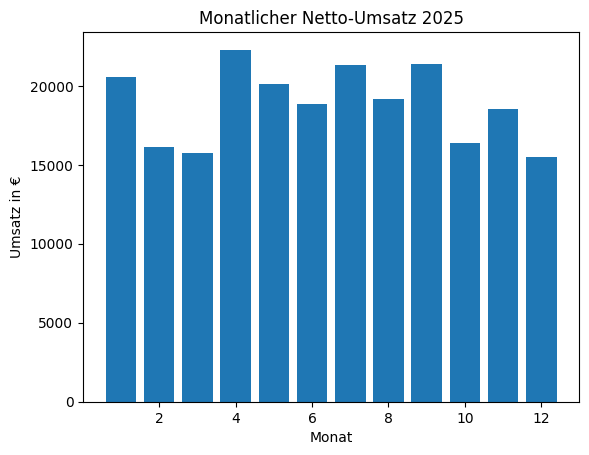

In [12]:
import matplotlib.pyplot as plt
plt.style.use("default")

# Ihre Loesung hier:
df_revenue = df[df['booking_type'] == "revenue"]
umsatzmonat = df_revenue.groupby(df_revenue.booking_date.dt.month)['amount_net'].sum()
plt.bar(umsatzmonat.index, umsatzmonat.values)
plt.title('Monatlicher Netto-Umsatz 2025')
plt.xlabel('Monat')
plt.ylabel('Umsatz in €')

---
## Hausaufgabe – Quartalsbericht

### Hausaufgabe – Quartalsbericht: Einnahmen vs. Ausgaben

Erstellen Sie einen kompakten Quartalsbericht auf Basis des Buchungsdatensatzes (buchung_2025.csv).
Die Aufgabe verbindet Datenbereinigung, Aggregation, Feature Engineering und Visualisierung.

**a) Vorbereitung**

Stellen Sie sicher, dass `booking_date` als Datumsspalte vorliegt und die Spalte `quarter` korrekt befüllt ist (z. B. `"Q1"`, `"Q2"`, ...).

**b) Aggregation: Einnahmen und Ausgaben pro Quartal**

Erstellen Sie eine Übersichtstabelle mit den Spalten `quarter`, `revenue` (Summe `amount_net` aller Einnahmen) und `expenses` (Summe `amount_net` aller Ausgaben). Fügen Sie eine Spalte `profit` hinzu, die die Differenz `revenue - expenses` zeigt.

Hinweis: Filtern Sie jeweils nach `booking_type == "revenue"` bzw. `"expense"` und führen Sie anschließend beide Ergebnisse zusammen.

**c) Visualisierung**

Stellen Sie `revenue` und `expenses` pro Quartal als **gruppiertes Balkendiagramm** dar. Beide Balkengruppen sollen nebeneinander erscheinen.

**d) Interpretation**

Schreiben Sie in einer Markdown-Zelle (oder als Kommentar) einen kurzen Satz zu folgenden Fragen:
- In welchem Quartal war der Gewinn am höchsten?
- Gibt es ein Quartal mit negativem Ergebnis?

<details>
<summary><b>Tipp zu b) – Aggregation und Zusammenführen</b></summary>

```python
rev = (
    df[df["booking_type"] == "revenue"]
    .groupby("quarter")["amount_net"]
    .sum()
    .rename("revenue")
)
exp = (
    df[df["booking_type"] == "expense"]
    .groupby("quarter")["amount_net"]
    .sum()
    .rename("expenses")
)
bericht = pd.concat([rev, exp], axis=1).fillna(0)
bericht["profit"] = bericht["revenue"] - bericht["expenses"]
```
</details>

<details>
<summary><b>Tipp zu c) – Gruppiertes Balkendiagramm</b></summary>

Ein pandas DataFrame mit mehreren Spalten kann direkt mit `.plot(kind="bar")` als gruppiertes Diagramm dargestellt werden:
```python
bericht[["revenue", "expenses"]].plot(kind="bar")
plt.title("Einnahmen vs. Ausgaben pro Quartal")
plt.xlabel("Quartal")
plt.ylabel("Netto-Betrag (€)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
```
</details>

<details>
<summary><b>Tipp zu d) – Bestes Quartal finden</b></summary>

Mit `.idxmax()` finden Sie das Quartal mit dem höchsten Wert in einer Spalte:
```python
bestes_quartal = bericht["profit"].idxmax()
```
</details>

               revenue   expense    profit
booking_date                              
1             52426.13  25715.36  26710.77
2             61214.76  26912.78  34301.98
3             61897.92  25845.26  36052.66
4             50388.23  18730.33  31657.90


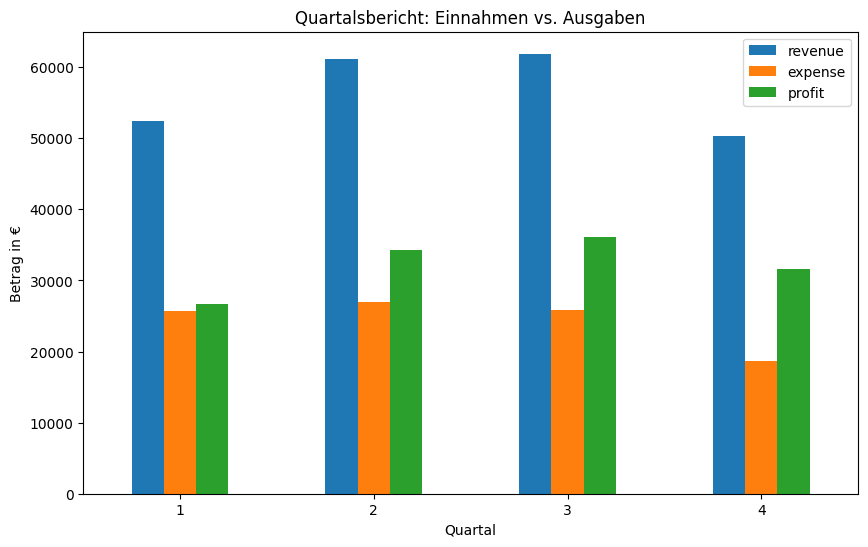

In [13]:
# Ihre Lösung hier:
##a)
df.booking_date
df.quarter.unique

#b)
df_expense = df[df['booking_type'] == "expense"]
df_revenue = df[df['booking_type'] == "revenue"]
profit = df_revenue.groupby(df_revenue.booking_date.dt.quarter)['amount_net'].sum() - df_expense.groupby(df_expense.booking_date.dt.quarter)['amount_net'].sum()
uebersicht = pd.DataFrame({'revenue': df_revenue.groupby(df_revenue.booking_date.dt.quarter)['amount_net'].sum(), 'expense': df_expense.groupby(df_expense.booking_date.dt.quarter)['amount_net'].sum(), 'profit': profit})
uebersicht = uebersicht.fillna(0)
uebersicht['profit'] = uebersicht['revenue'] - uebersicht['expense']
print(uebersicht)
uebersicht.plot(kind='bar', y=['revenue', 'expense', 'profit'], figsize=(10, 6))
plt.title('Quartalsbericht: Einnahmen vs. Ausgaben')
plt.xlabel('Quartal')
plt.ylabel('Betrag in €')
plt.xticks(rotation=0)
plt.show()